In [1]:
import plotly

In [2]:
import numpy as np
import pandas as pd

About Plotly
Plotly is a Data Viz library by the company Plotly based out of Canada with support in languages such as Python, Js, Julia etc.

Advantages
Multi language support
Lot's of graphs
Interactive plots
Beautiful plots
Does not work with live data streams. Dash can be explored for that.

The Plotly Roadmap
Plotly Go
Plotly Express
Dash

In [3]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import plotly.express as px

In [4]:
tips=px.data.tips()

In [5]:
iris=px.data.iris()
gap=px.data.gapminder()

In [6]:
gap

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [7]:
temp_df=gap[gap['year']==2007]

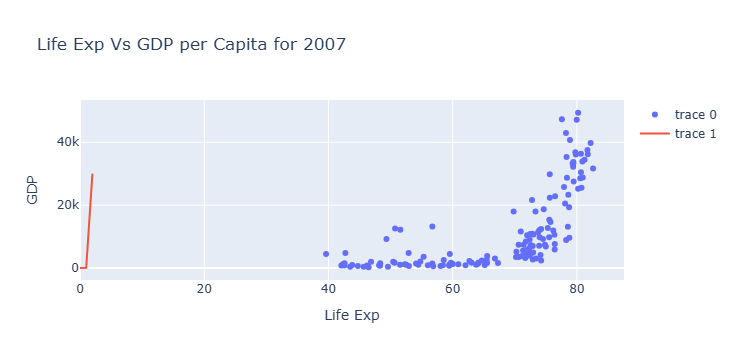

In [16]:
tr1=go.Scatter(x=temp_df['lifeExp'],y=temp_df['gdpPercap'],mode='markers')
trace2 = go.Scatter(x=[0,1,2],y=[0,90,30000],mode='lines')
layout = go.Layout(title='Life Exp Vs GDP per Capita for 2007', xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
data=[tr1,trace2]
fig = go.Figure(data,layout)
fig.show()

In [17]:
## plot life exp and gdp scatter plot -> continent as color -> pop as size ->
#hover name -> range_x/range_y -> log_x/log_y

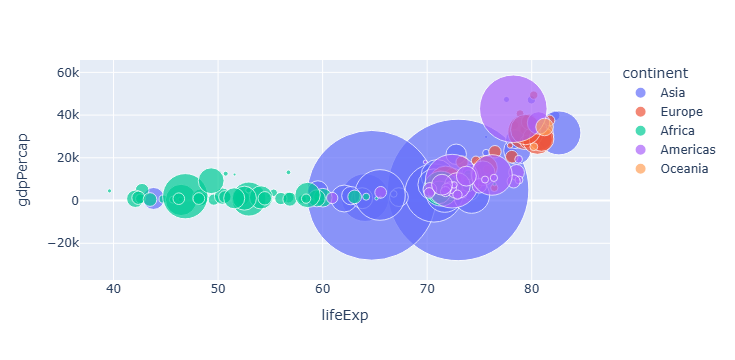

In [20]:
px.scatter(temp_df,x=temp_df['lifeExp'],y=temp_df['gdpPercap'],color=temp_df['continent'],size=temp_df['pop'],
          size_max=100,hover_name='country')

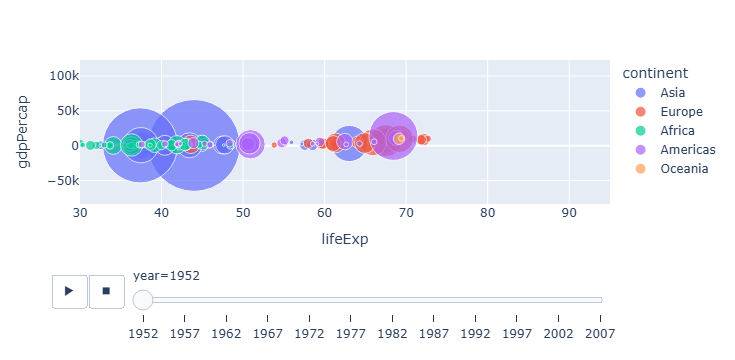

In [22]:
# plot animation of the above curve on the basic of year
px.scatter(gap,x='lifeExp',y='gdpPercap',color='continent',size='pop',
          size_max=100,hover_name='country',range_x=[30,95],animation_frame='year',animation_group='country')

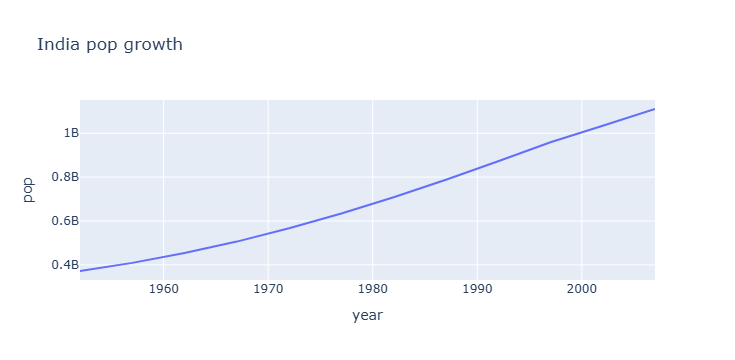

In [23]:
# line plot
# plot india pop line plot
temp_df = gap[gap['country'] == 'India']

px.line(temp_df, x='year', y='pop',title='India pop growth')

In [33]:
ipc=gap[gap['country'].isin(['India','Pakistan','China'])].pivot(index='year',values='lifeExp',columns='country')

In [34]:
ipc.head()

country,China,India,Pakistan
year,,,
1952,44.00000,37.373,43.436
1957,50.54896,40.249,45.557
1962,44.50136,43.605,47.670
1967,58.38112,47.193,49.800
1972,63.11888,50.651,51.929


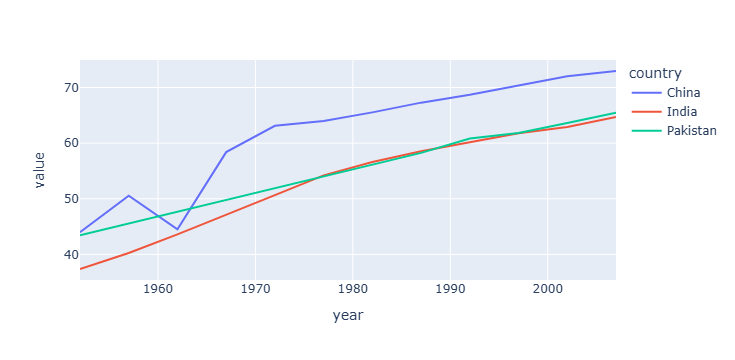

In [36]:
px.line(ipc,x=ipc.index,y=ipc.columns)

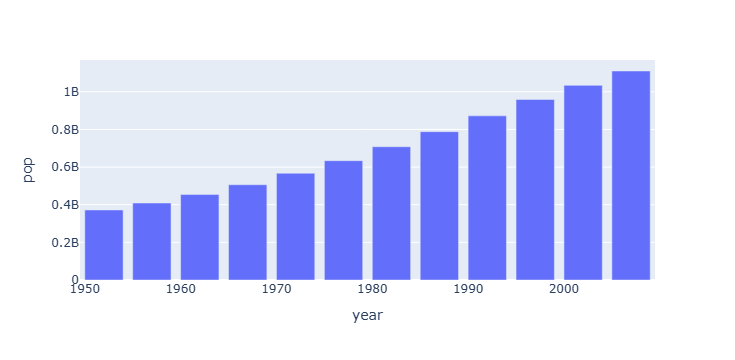

In [38]:
#yearbyyear India pop
ind=gap[gap['country']=='India']
px.bar(ind,x='year',y='pop')

In [39]:
ipc=gap[gap['country'].isin(['India','Pakistan','China'])].pivot(index='year',values='pop',columns='country')

In [40]:
ipc

country,China,India,Pakistan
year,,,
1952,556263527,372000000,41346560
1957,637408000,409000000,46679944
1962,665770000,454000000,53100671
1967,754550000,506000000,60641899
1972,862030000,567000000,69325921
1977,943455000,634000000,78152686
1982,1000281000,708000000,91462088
1987,1084035000,788000000,105186881
1992,1164970000,872000000,120065004


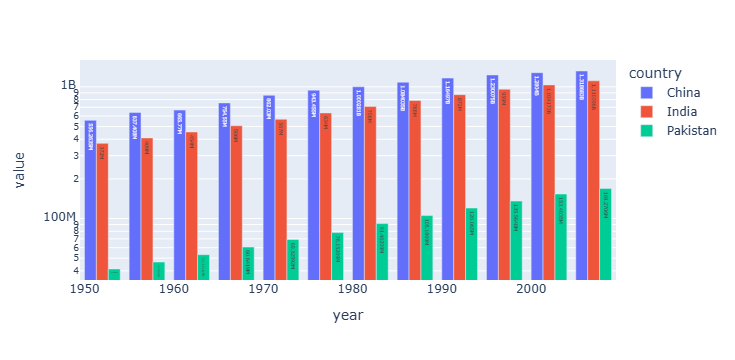

In [44]:
px.bar(ipc,barmode='group',log_y=True,text_auto=True)

In [46]:
# stacked bar chart
# pop contribution per country to a continents pop stacked for a particular year(2007)
temp_df=gap[gap['year']==2007]

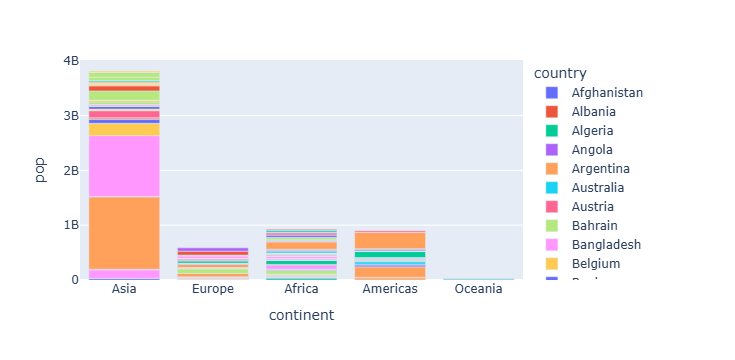

In [51]:
px.bar(temp_df,x='continent',y='pop',color='country')

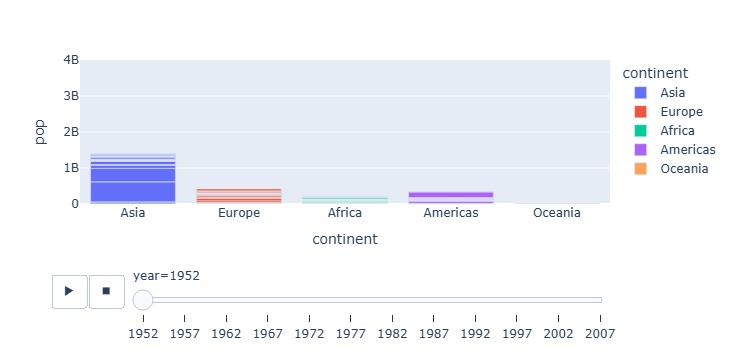

In [52]:
# bar chart animation
px.bar(gap, x='continent',y='pop',color='continent',animation_frame='year',animation_group='country',range_y=[0,4000000000])

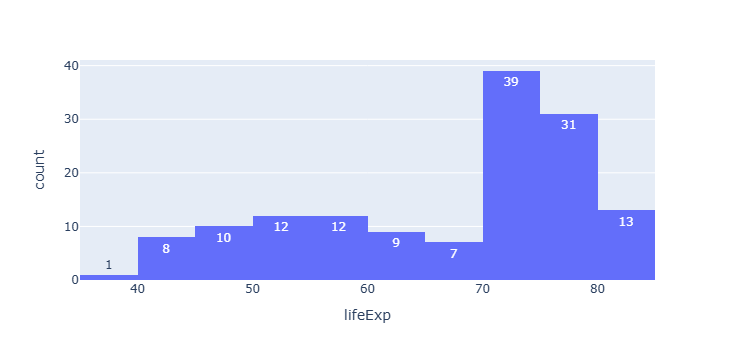

In [54]:
px.histogram(temp_df,x='lifeExp',nbins=10,text_auto=True)

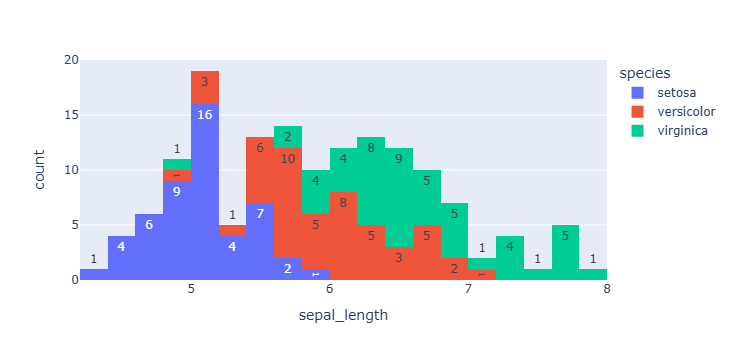

In [55]:
px.histogram(iris,x='sepal_length',color='species',nbins=30,text_auto=True)

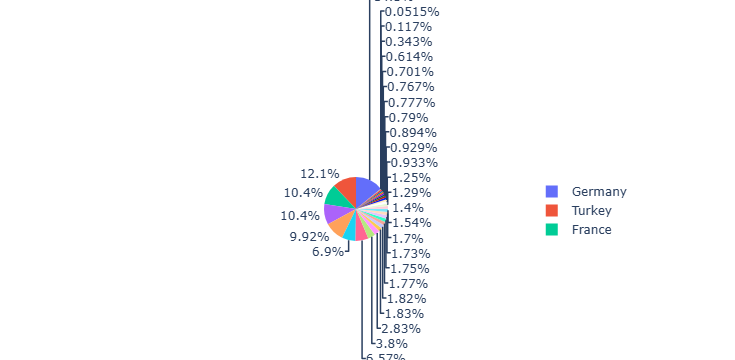

In [56]:
# Pie -> values -> names
# find the pie chart of pop of european countries in 2007

temp_df = gap[(gap['year'] == 2007) & (gap['continent'] == 'Europe')]

px.pie(temp_df, values='pop', names='country')

In [58]:
one952=gap[gap['year']==1952].groupby('continent')['pop'].sum().reset_index()

In [59]:
one952

,continent,pop
0,Africa,237640501
1,Americas,345152446
2,Asia,1395357351
3,Europe,418120846
4,Oceania,10686006


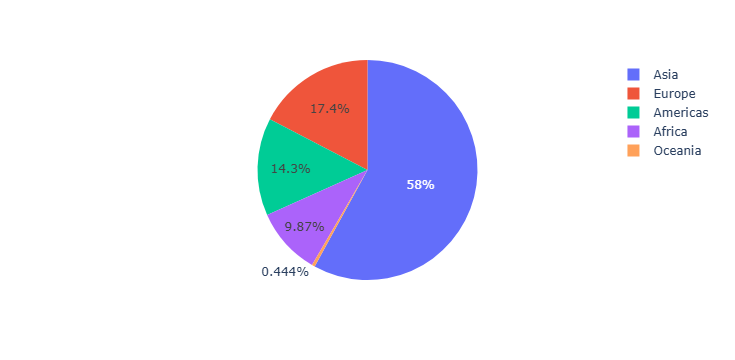

In [61]:
px.pie(one952,values='pop',names='continent')

In [62]:
# Sunburst plot -> Sunburst plots visualize hierarchical data spanning outwards radially from root to leaves. -> color
# path -> [], values

In [64]:
temp_df=gap[gap['year']==2007]

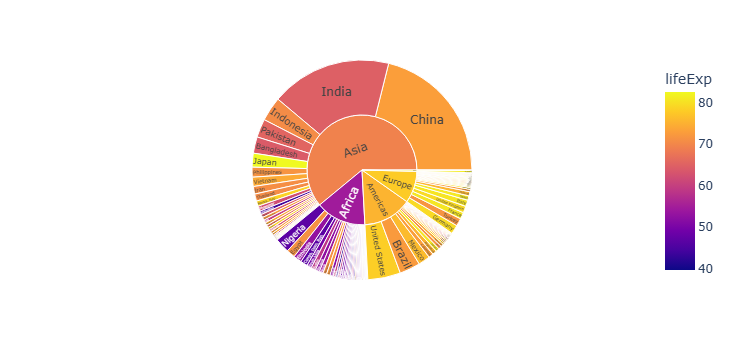

In [68]:
px.sunburst(temp_df,path=['continent','country'],values='pop',color='lifeExp')

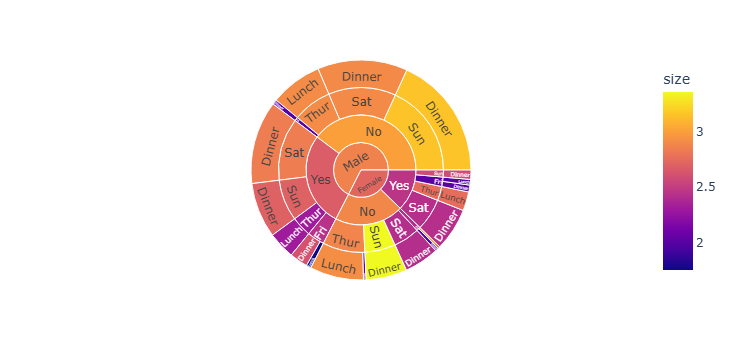

In [69]:
px.sunburst(tips,path=['sex','smoker','day','time'],values='total_bill',color='size')

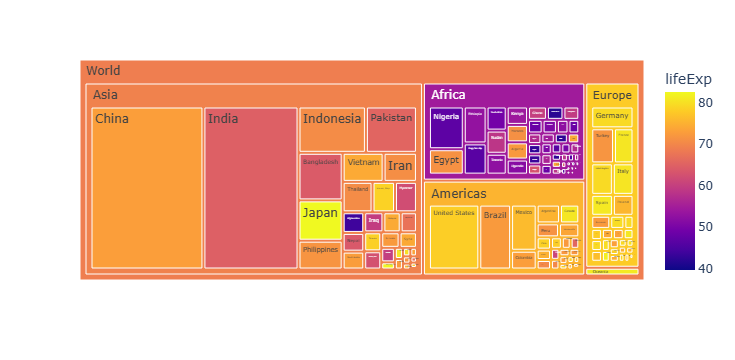

In [70]:
# Treemap
temp_df = gap[gap['year'] == 2007]

px.treemap(temp_df, path=[px.Constant('World'),'continent','country'],values='pop',color='lifeExp')

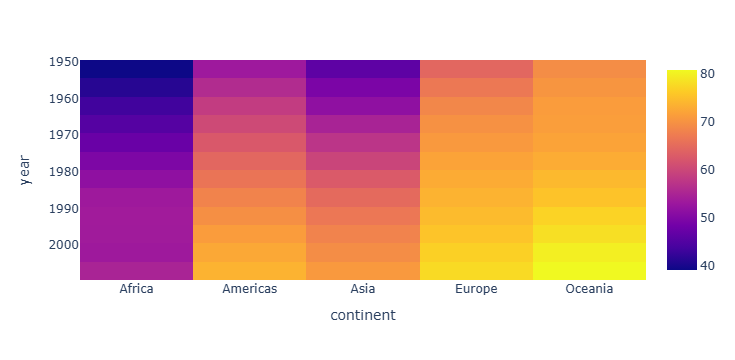

In [71]:
temp_df = gap.pivot_table(index='year',columns='continent',values='lifeExp',aggfunc='mean')
px.imshow(temp_df)

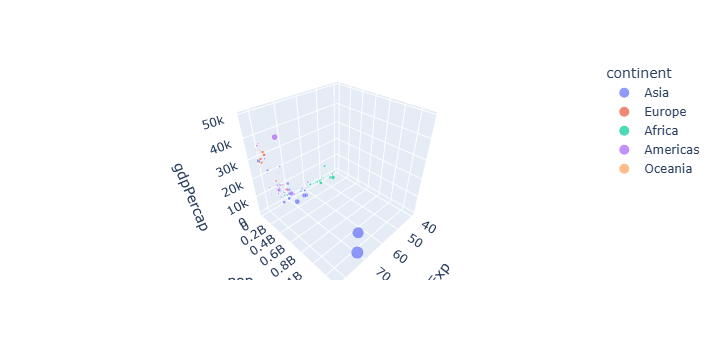

In [77]:
#3d scatterplot
# plot a 3d scatter plot of all country data for 2007
temp_df = gap[gap['year'] == 2007]
px.scatter_3d(temp_df, x='lifeExp',y='pop',z='gdpPercap',color='continent',hover_name='country',size='pop')

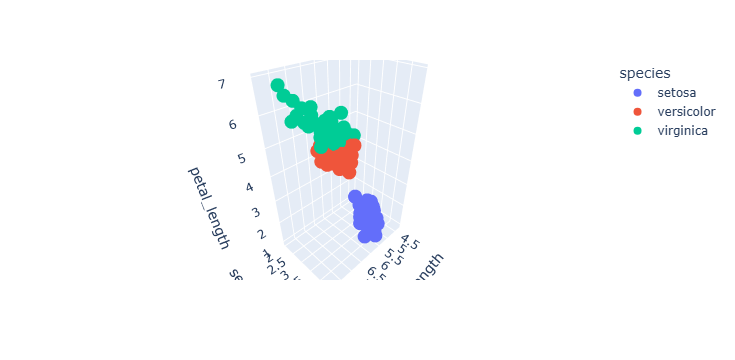

In [78]:
px.scatter_3d(iris,x='sepal_length',y='sepal_width',z='petal_length',color='species')

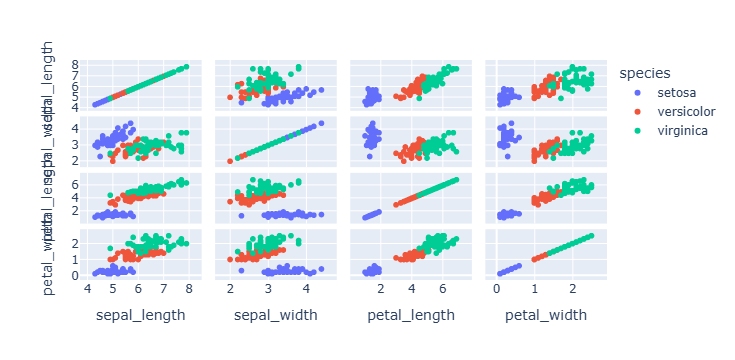

In [79]:
px.scatter_matrix(iris,dimensions=['sepal_length','sepal_width','petal_length','petal_width'],color='species')

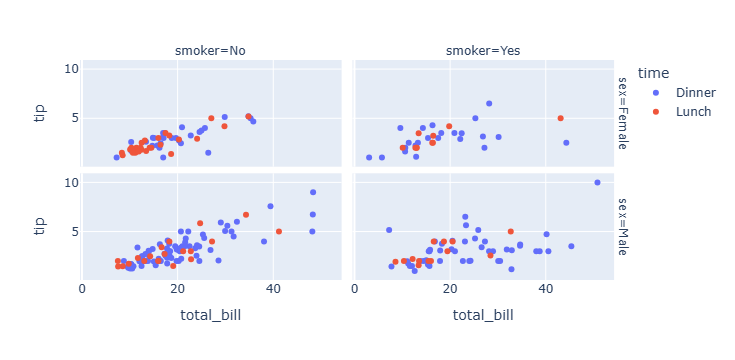

In [80]:
px.scatter(tips, x='total_bill', y='tip', facet_col='smoker', facet_row='sex',color='time')

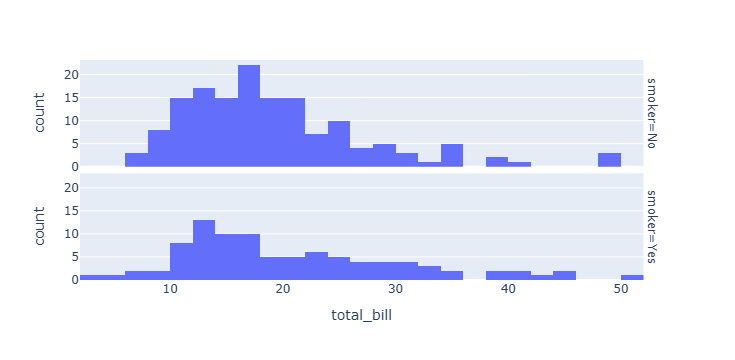

In [82]:
px.histogram(tips,x='total_bill',facet_row='smoker')

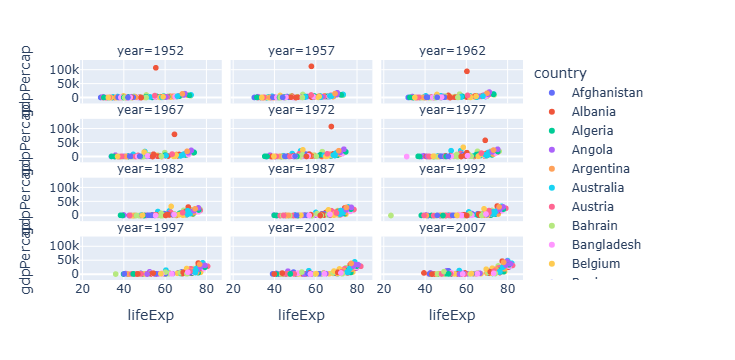

In [84]:
px.scatter(gap, x='lifeExp', y='gdpPercap', facet_col='year',color='country', facet_col_wrap=3)

In [85]:
# 3d Surface plot
# can not be created using Plotly express
# we will use plotly graph object -> go

x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx, yy = np.meshgrid(x,y)

z = xx**2 + yy**2
# z = np.sin(xx) + np.tan(yy)
# z = np.sqrt(xx**2 + yy**2)

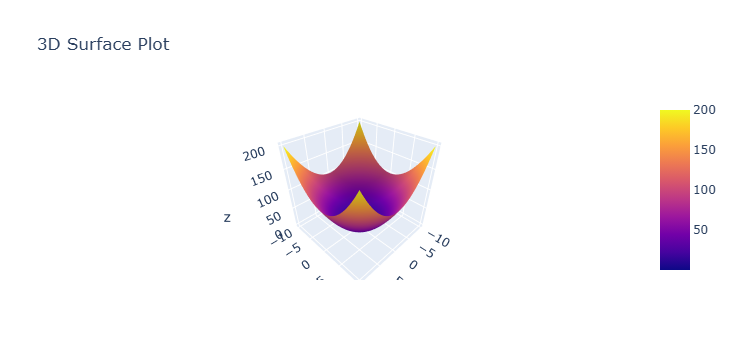

In [86]:

trace = go.Surface(x=x,y=y,z=z)

data = [trace]

layout = go.Layout(title='3D Surface Plot')

fig = go.Figure(data,layout)

fig.show()

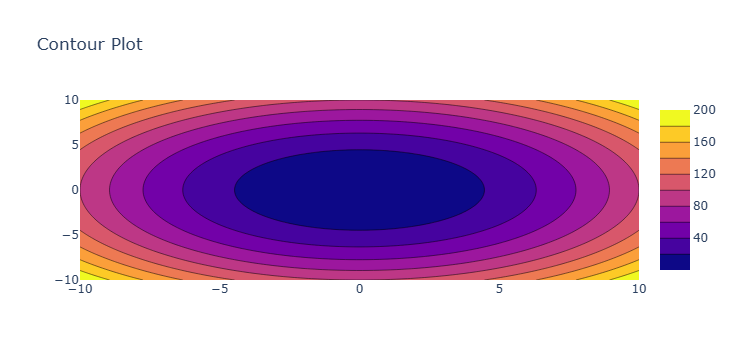

In [88]:

trace = go.Contour(x=x,y=y,z=z)

data = [trace]

layout = go.Layout(title='Contour Plot')

fig = go.Figure(data,layout)

fig.show()

In [89]:
# Subplots
from plotly.subplots import make_subplots

In [90]:
fig = make_subplots(rows=2,cols=2)

In [96]:
fig.add_trace(
    go.Scatter(x=[1,9,5],y=[2,10,1]),
    row = 1,
    col = 1
)

fig.add_trace(
    go.Histogram(x=[1,9,5,22,109,134,56,78,12,34,89]),
    row = 1,
    col = 2
)

fig.add_trace(
    px.scatter(x=[1,9,5],y=[2,10,1]),
    row = 2,
    col = 1
)

fig.add_trace(
    go.Histogram(x=[1,9,5,22,109,134,56,78,12,34,89]),
    row = 2,
    col = 2
)

fig.update_layout(title='Subplots')

fig.show()


ValueError: 
    Invalid element(s) received for the 'data' property of 
        Invalid elements include: [Figure({
    'data': [{'hovertemplate': 'x=%{x}<br>y=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': array([1, 9, 5], dtype=int64),
              'xaxis': 'x',
              'y': array([ 2, 10,  1], dtype=int64),
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'x'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'y'}}}
})]

    The 'data' property is a tuple of trace instances
    that may be specified as:
      - A list o